<a href="https://colab.research.google.com/github/wahiwatkar06-gif/mdm-practicals/blob/main/Practical_No10_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
def preprocess_data(x, y, limit):
    x = x.reshape(x.shape[0], 28 * 28, 1)
    x = x.astype("float32") / 255

    y = to_categorical(y, num_classes=10)
    y = y.reshape(y.shape[0], 10, 1)

    return x[:limit], y[:limit]

In [ ]:

import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load the MNIST handwritten digit dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Preprocess images and labels
def preprocess_data(x, y, limit):
    x = x.reshape(x.shape[0], 28 * 28, 1)
    x = x.astype("float32") / 255.0

    y = to_categorical(y, num_classes=10)
    y = y.reshape(y.shape[0], 10, 1)

    return x[:limit], y[:limit]

# Use a smaller dataset initially so training finishes faster
x_train, y_train = preprocess_data(x_train, y_train, 1000)
x_test, y_test = preprocess_data(x_test, y_test, 200)

print("Dataset loaded successfully!")
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!
Training images: (1000, 784, 1)
Training labels: (1000, 10, 1)
Test images: (200, 784, 1)
Test labels: (200, 10, 1)


In [ ]:
def predict(network, input):
    output = input
    for layer in network:
        output = layer.forward(output)
    return output

In [ ]:
!pip install simple-colors

In [ ]:

import simple_colors

Epoch 1/50, error=0.128093
Epoch 2/50, error=0.091490
Epoch 3/50, error=0.089452
Epoch 4/50, error=0.088832
Epoch 5/50, error=0.088457
Epoch 6/50, error=0.088139
Epoch 7/50, error=0.087830
Epoch 8/50, error=0.087515
Epoch 9/50, error=0.087188
Epoch 10/50, error=0.086847
Epoch 11/50, error=0.086488
Epoch 12/50, error=0.086110
Epoch 13/50, error=0.085712
Epoch 14/50, error=0.085292
Epoch 15/50, error=0.084848
Epoch 16/50, error=0.084379
Epoch 17/50, error=0.083883
Epoch 18/50, error=0.083359
Epoch 19/50, error=0.082806
Epoch 20/50, error=0.082222
Epoch 21/50, error=0.081608
Epoch 22/50, error=0.080961
Epoch 23/50, error=0.080284
Epoch 24/50, error=0.079575
Epoch 25/50, error=0.078837
Epoch 26/50, error=0.078070
Epoch 27/50, error=0.077278
Epoch 28/50, error=0.076462
Epoch 29/50, error=0.075626
Epoch 30/50, error=0.074773
Epoch 31/50, error=0.073905
Epoch 32/50, error=0.073026
Epoch 33/50, error=0.072141
Epoch 34/50, error=0.071251
Epoch 35/50, error=0.070359
Epoch 36/50, error=0.069469
E

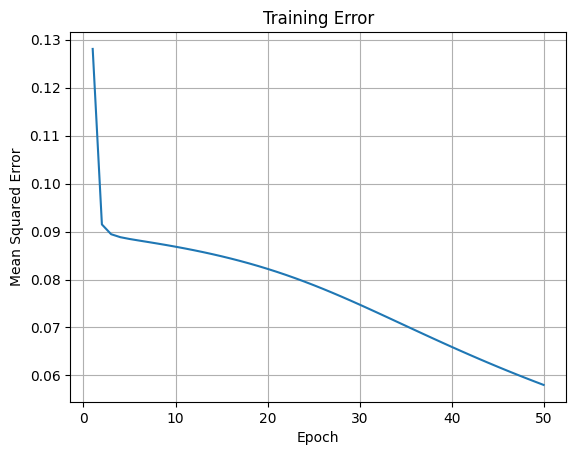

In [ ]:

network = [
    Dense(784, 80),
    Sigmoid(),
    Dense(80, 10),
    Sigmoid()
]

epochs = 50
learning_rate = 0.01
errorlist = []

for e in range(epochs):
    error = 0.0

    for x, y in zip(x_train, y_train):
        output = x

        for layer in network:
            output = layer.forward(output)

        error += float(np.asarray(mse(y, output)).mean())
        grad = mse_prime(y, output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)

    error /= len(x_train)
    errorlist.append(error)
    print(f"Epoch {e + 1}/{epochs}, error={error:.6f}")

import matplotlib.pyplot as plt

plt.plot(range(1, epochs + 1), errorlist)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training Error")
plt.grid(True)
plt.show()
